<a href="https://colab.research.google.com/github/Dinusha-Ekanayake/River_WaterLevel_Preliminary_Analysis/blob/main/River_WaterLevel_Task1%262_Full_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# River Water Level Forecasting - Regression Analysis (Task 1)

**Practical Assignment: Regression Analysis**

**Name:** Ekanayake D.B  
**Index No:** 235514B

**Dataset:** Islandwide Water Level and Rainfall Situation in Major Rivers of Sri Lanka

---

## Objective

Develop a regression model capable of predicting the river water level **12 hours ahead** (`Water_Level_Xt`) from the current river water level and the previous 24 hours of rainfall.

## Variables

| Variable | Description | Role |
|---|---|---|
| `Gauging_station` | Identifier of the gauging station | Identifier only |
| `Water_Level_Xt_1` | River water level (mm) at time t | Predictor (X1) |
| `24HrRF_Xt_1` | Total rainfall (mm) in the previous 24 hours at time t | Predictor (X2) |
| `Water_Level_Xt` | River water level (mm) at time t + 12 hours | Target (Y) |

## Contents

1. Setup and data loading  
2. Exploratory data analysis  
3. Data preprocessing  
4. Model development - univariate regression  
5. Model development - multivariate regression  
6. Model diagnostics  
7. Model evaluation  
8. Practical usefulness of the model  
9. Strengths and limitations  


## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

df = pd.read_csv("training_data.csv")
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (78, 4)


,Gauging_station,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
0,1,2.9000,NaN,1.5000
1,2,5.0000,23.2000,3.7100
2,3,12.6800,44.3000,11.0500
3,4,1.6000,51.7000,1.8100
4,5,1.2800,81.2000,0.8700
5,6,1.3100,78.7000,1.1000
6,7,0.6300,18.6000,0.6100
7,8,2.3000,12.1000,2.3600
8,9,8.1000,72.3000,7.9200
9,10,3.5600,46.3000,2.4100


The training dataset is loaded. It contains 78 rows and 4 columns. Each row represents one observation from a gauging station. The three measurement columns are numeric float values; `Gauging_station` is an integer identifier that will not be used as a predictor.

## 2. Exploratory data analysis

### 2.1 Data types and basic structure

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gauging_station   78 non-null     int64  
 1   Water_Level_Xt_1  78 non-null     float64
 2   24HrRF_Xt_1       76 non-null     float64
 3   Water_Level_Xt    72 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.6 KB


This DataFrame contains 78 entries and 4 columns. It includes `Gauging_station` (integer), `Water_Level_Xt_1` (float), `24HrRF_Xt_1` (float), and `Water_Level_Xt` (float). There are missing values in `24HrRF_Xt_1` (76 non null) and `Water_Level_Xt` (72 non-null). The DataFrame uses approximately 2.6 KB of memory.

### 2.2 Descriptive statistics

In [3]:
df[["Water_Level_Xt_1", "24HrRF_Xt_1", "Water_Level_Xt"]].describe()

,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
count,78.0000,76.0000,72.0000
mean,2.1333,21.4408,2.1449
std,2.5934,21.4245,2.3772
min,-3.2700,0.0000,-0.1300
25%,0.6300,3.3250,0.6175
50%,1.3250,14.9500,1.3550
75%,2.9525,32.3000,2.6525
max,12.6800,81.2000,11.7300


Several features emerge from the descriptive statistics:

- The current water level (`Water_Level_Xt_1`) and the target (`Water_Level_Xt`) have very similar means (about 2.1 mm), standard deviations, and quartiles. This reflects the physical reality that the river level changes gradually over a 12 hour window, so the current level is a strong baseline for what the level will be 12 hours later.
- Rainfall (`24HrRF_Xt_1`) ranges from 0 mm (dry) up to 81.2 mm (heavy event). The mean (21.4 mm) exceeds the median, indicating a right skewed distribution.
- Both water level columns show minimum values below zero. These are physically valid readings recorded
  relative to a station specific reference data point. a negative reading simply means the water surface
  is below that data point and is not an error.
- The count for `24HrRF_Xt_1` (76) and `Water_Level_Xt` (72) is below 78, confirming missing values
  that are addressed in preprocessing.

### 2.3 Missing value analysis

In [4]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
miss_table = pd.DataFrame({"Missing count": missing, "Missing (%)": missing_pct})
print(miss_table)
print()
print("Stations missing 24HrRF_Xt_1:", df.loc[df["24HrRF_Xt_1"].isna(), "Gauging_station"].tolist())
print("Stations missing Water_Level_Xt:", df.loc[df["Water_Level_Xt"].isna(), "Gauging_station"].tolist())
print()
print("Fully complete rows:", df.dropna().shape[0])

                  Missing count  Missing (%)
Gauging_station               0       0.0000
Water_Level_Xt_1              0       0.0000
24HrRF_Xt_1                   2       2.5600
Water_Level_Xt                6       7.6900

Stations missing 24HrRF_Xt_1: [1, 40]
Stations missing Water_Level_Xt: [28, 34, 35, 67, 73, 74]

Fully complete rows: 70


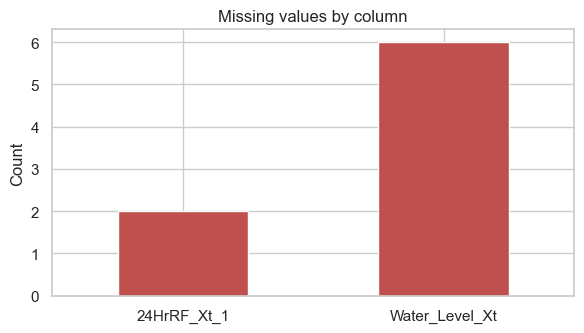

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
missing[missing > 0].plot(kind="bar", color="#c0504d", ax=ax)
ax.set_title("Missing values by column")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

There are two distinct missing data situations:

- `24HrRF_Xt_1` is missing for stations 1 and 40. These rows have valid current water levels and valid
  targets, so they can be recovered by imputation.
- `Water_Level_Xt` (the target) is missing for stations 28, 34, 35, 67, 73, and 74. A supervised
  regression model cannot be trained on rows that have no target value, and imputing a target would
  fabricate the very quantity the model is trying to learn. These 6 rows will be excluded from training dataset.

The two groups do not overlap, leaving 78 - 6 = 72 usable training rows after the missing target rows are
removed.

### 2.4 Distribution of variables

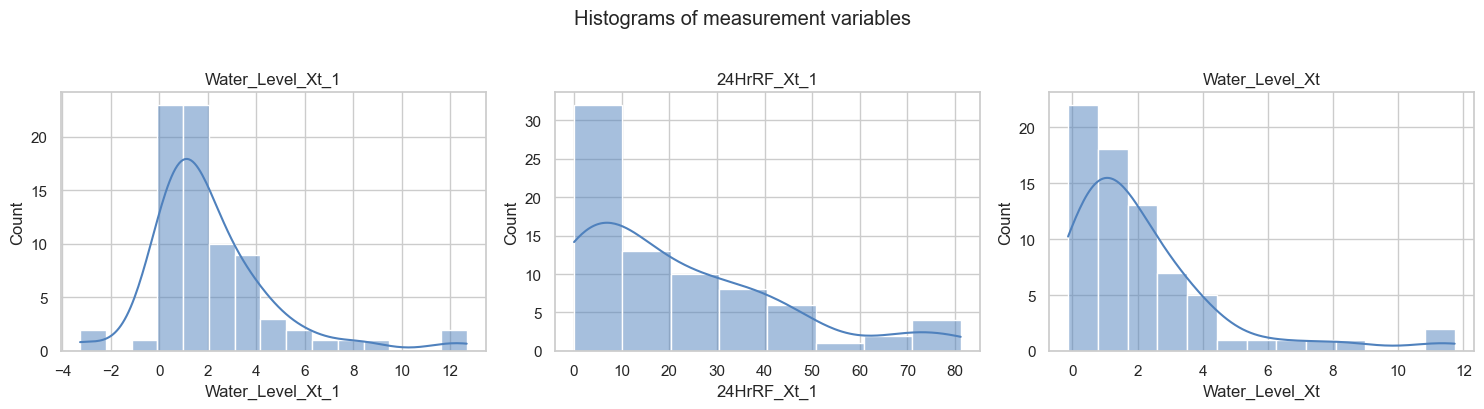

Skewness:
Water_Level_Xt_1   1.8080
24HrRF_Xt_1        1.1330
Water_Level_Xt     2.2560


In [6]:
num_cols = ["Water_Level_Xt_1", "24HrRF_Xt_1", "Water_Level_Xt"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4f81bd")
    ax.set_title(col)
plt.suptitle("Histograms of measurement variables", y=1.02)
plt.tight_layout()
plt.show()

print("Skewness:")
print(df[num_cols].skew().round(3).to_string())

All three variables are positive skewed (skewness values of approximately 2.2, 1.1, and 2.2
respectively). The distributions have long upper tails driven by a small number of high flow stations and
heavy rain events. The all of the observations sit at low water levels and low or zero rainfall.

### 2.5 Boxplots and outlier inspection

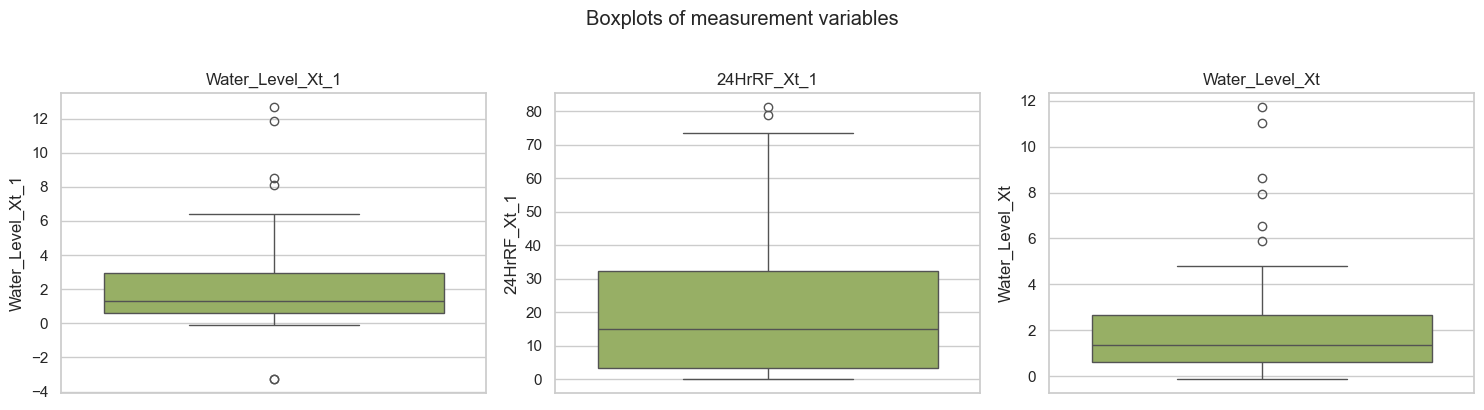

IQR-based outlier check (1.5 x IQR rule):
  Water_Level_Xt_1: fence [-2.85, 6.44], flagged stations = [3, 9, 28, 42, 48, 67]
  24HrRF_Xt_1: fence [-40.14, 75.76], flagged stations = [5, 6]
  Water_Level_Xt: fence [-2.44, 5.71], flagged stations = [3, 9, 12, 42, 48, 51]


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#9bbb59")
    ax.set_title(col)
plt.suptitle("Boxplots of measurement variables", y=1.02)
plt.tight_layout()
plt.show()

print("IQR-based outlier check (1.5 x IQR rule):")
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = df.loc[(df[col] < lo) | (df[col] > hi), "Gauging_station"].tolist()
    print(f"  {col}: fence [{lo:.2f}, {hi:.2f}], flagged stations = {flagged}")

The IQR depicts that several stations at the upper end of the water level columns (for example,
stations 3, 9, 42, and 48). These correspond to genuinely large rivers carrying high flow and are real
measurements, not errors. Removing them would discard exactly the high water level behaviour the model
needs to capture. Therefore they will remain throughout the analysis.

The negative water levels seen at the lower fence are valid as explained earlier. Two of these
(stations 28 and 67) are among the rows whose target is missing, so they are removed during preprocessing
for that separate reason.

### 2.6 Correlation analysis

Correlation Matrix:
                  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
Water_Level_Xt_1            1.0000       0.3634          0.9899
24HrRF_Xt_1                 0.3634       1.0000          0.3161
Water_Level_Xt              0.9899       0.3161          1.0000


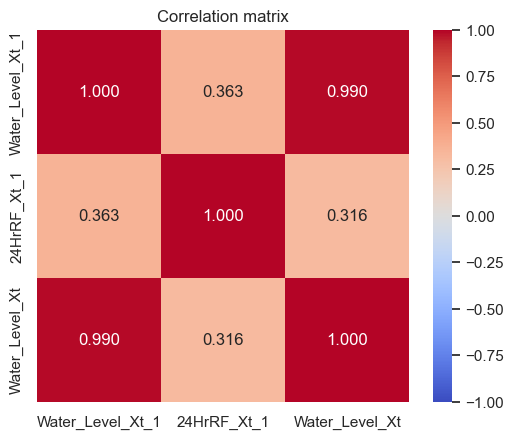

In [8]:
corr = df[num_cols].corr()
print("Correlation Matrix:")
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

The correlation matrix reveals the central finding of the exploratory analysis:

- `Water_Level_Xt_1` and the target `Water_Level_Xt` have a correlation of approximately **0.99**. The
  current water level is an extremely strong linear predictor of the level 12 hours ahead.
- `24HrRF_Xt_1` has a much weaker correlation with the target (approximately **0.32**). Rainfall carries
  some predictive information, but far less than the current level alone.
- The two predictors are only moderately correlated with each other (approximately **0.36**), which means
  multicollinearity is not expected to be a serious concern when both are used together.

### 2.7 Scatter plots of predictor-target relationships

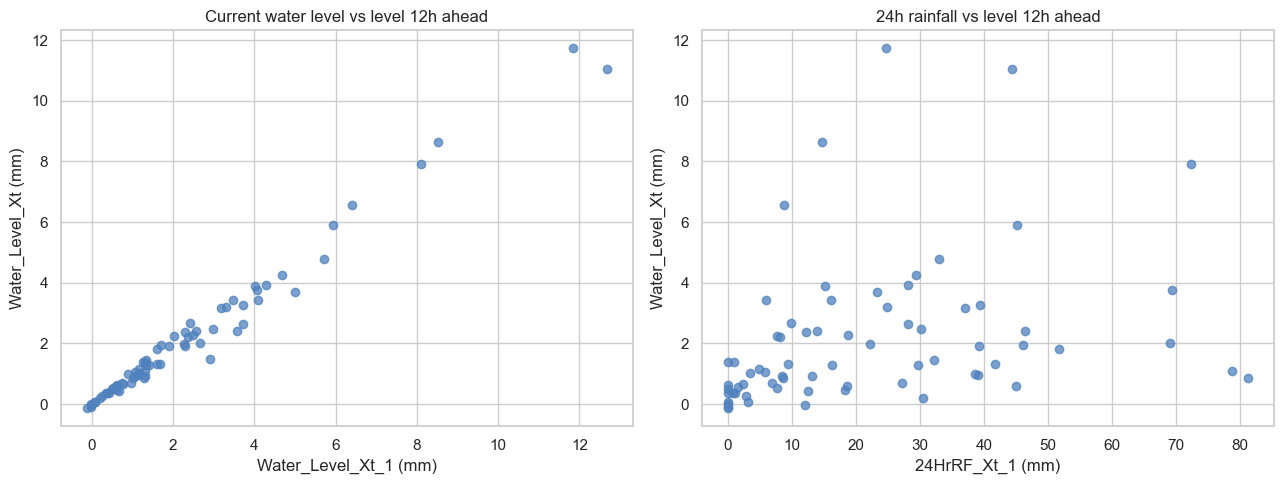

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Water_Level_Xt_1"], df["Water_Level_Xt"],
                color="#4f81bd", alpha=0.75)
axes[0].set_xlabel("Water_Level_Xt_1 (mm)")
axes[0].set_ylabel("Water_Level_Xt (mm)")
axes[0].set_title("Current water level vs level 12h ahead")

axes[1].scatter(df["24HrRF_Xt_1"], df["Water_Level_Xt"],
                color="#4f81bd", alpha=0.75)
axes[1].set_xlabel("24HrRF_Xt_1 (mm)")
axes[1].set_ylabel("Water_Level_Xt (mm)")
axes[1].set_title("24h rainfall vs level 12h ahead")

plt.tight_layout()
plt.show()

The left scatter plot shows a tight, near linear relationship between the current water level and
the target, consistent with the 0.99 correlation. The right scatter shows only a diffuse cloud for
rainfall, with no clear strong trend. These patterns confirm that a linear regression approach is
appropriate, and that the current water level will dominate the model.

### 2.8 Pairwise relationships

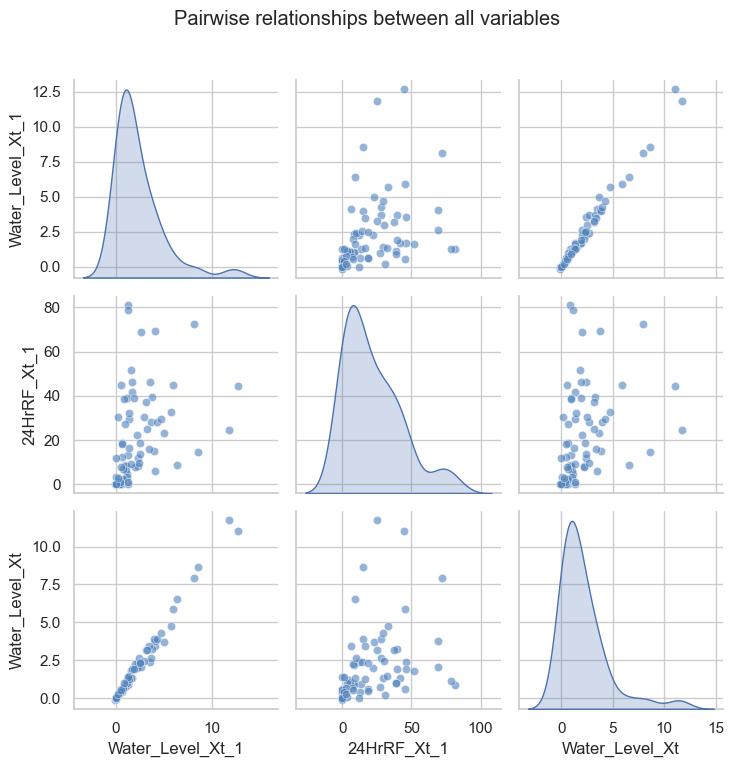

In [10]:
sns.pairplot(df[num_cols].dropna(), diag_kind="kde",
             plot_kws={"alpha": 0.6, "color": "#4f81bd"})
plt.suptitle("Pairwise relationships between all variables", y=1.02)
plt.tight_layout()
plt.show()

## 3. Data preprocessing

Based on the exploratory analysis, the preprocessing steps are:

1. Remove `Gauging_station` from the modelling variables (identifier, not a predictor).
2. Drop **all rows** that contain any missing value (listwise deletion).

This removes the 6 rows with a missing target and the 2 rows with missing rainfall, leaving **70 complete observations** for modelling.

In [11]:
# Step 1: Separate the identifier
station_id = df["Gauging_station"].copy()
data = df.drop(columns=["Gauging_station"]).copy()

# Step 2: Drop all rows with any missing value (listwise deletion)
before = len(data)
data = data.dropna().copy()
print(f"Removed {before - len(data)} rows with at least one missing value.")
print(f"Remaining rows: {len(data)}")

# Verify
print(f"\nMissing values remaining: {data.isna().sum().sum()}")
print(f"Final modelling dataset shape: {data.shape}")

Removed 8 rows with at least one missing value.
Remaining rows: 70

Missing values remaining: 0
Final modelling dataset shape: (70, 3)


`Gauging_station` is an arbitrary label; using it as a numeric predictor would introduce a meaningless ordering into the model. It is therefore kept only for reference and removed from the modelling frame.

Listwise deletion (dropping every row that has any missing value) is chosen here over imputation. With only 8 affected rows out of 78 (10.3%), the loss of information is small. More importantly, imputing the target (`Water_Level_Xt`) would fabricate the very quantity the model is trying to learn, and imputing rainfall (`24HrRF_Xt_1`) introduces artificial values that could bias the rainfall coefficient. Dropping them avoids both risks and leaves 70 fully observed, reliable rows for estimation.

All valid outliers and negative water level readings are kept because they represent real physical conditions the model should learn.

In [12]:
print("Clean dataset summary statistics:")
data.describe()

Clean dataset summary statistics:


,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
count,70.0000,70.0000,70.0000
mean,2.3381,21.9457,2.1576
std,2.5538,20.8120,2.4100
min,-0.1200,0.0000,-0.1300
25%,0.6400,5.8500,0.6125
50%,1.3400,15.6500,1.3250
75%,3.2675,32.7000,2.6575
max,12.6800,81.2000,11.7300


## 4. Model development - Univariate (simple linear) regression

### 4.1 Model specification

The univariate model uses only the current water level as the predictor:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1$$

where $Y$ is `Water_Level_Xt` (level 12 hours ahead) and $X_1$ is `Water_Level_Xt_1`
(current water level). Parameters are estimated by ordinary least squares (OLS), which will minimizes the sum of squared residuals.

In [13]:
y = data["Water_Level_Xt"]

# Define predictor and add the constant (intercept) term
X_uni = sm.add_constant(data[["Water_Level_Xt_1"]])

# Fit the OLS model
model_uni = sm.OLS(y, X_uni).fit()

print(model_uni.summary())

                            OLS Regression Results                            
Dep. Variable:         Water_Level_Xt   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     4031.
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           2.91e-62
Time:                        11:57:00   Log-Likelihood:                -16.934
No. Observations:                  70   AIC:                             37.87
Df Residuals:                      68   BIC:                             42.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0305      0.051  

### 4.2 Interpretation of the univariate model

**Fitted equation:**

$$\hat{Y} = -0.0467 + 0.9344 \cdot X_1$$

- **Intercept (-0.0467):** The predicted water level 12 hours ahead when the current level is 0 mm.
  In practice this has no direct physical meaning because a reading of exactly 0 is a data point crossing rather than a meaningful condition. The intercept is not statistically significant (p = 0.398),
  which is consistent with this interpretation.
- **Slope (0.9344):** For every 1 mm increase in the current water level, the predicted level 12 hours
  later increases by approximately 0.93 mm, holding all else constant. The slope is very close to 1,
  meaning the river level is nearly persistent over a 12 hour period. This coefficient is highly
  statistically significant (p < 0.0001).

**Overall model fit:**

- R squared = 0.980. the current water level alone explains approximately **98.0%** of the variation
  in the level 12 hours ahead. This is an exceptionally high fit.
- The F-statistic tests the overall significance of the regression model. So it (3410, p < 0.0001) confirms that the model as a whole is statistically significant.

### 4.3 Fitted line plot

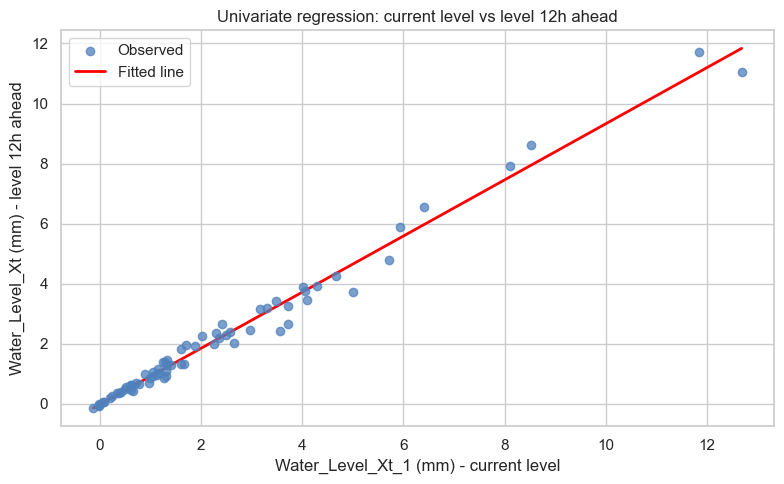

In [14]:
x_range = np.linspace(data["Water_Level_Xt_1"].min(),
                      data["Water_Level_Xt_1"].max(), 200)
y_fitted = model_uni.params["const"] + model_uni.params["Water_Level_Xt_1"] * x_range

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data["Water_Level_Xt_1"], y, color="#4f81bd",
           alpha=0.75, label="Observed", zorder=3)
ax.plot(x_range, y_fitted, color="red", linewidth=2, label="Fitted line")
ax.set_xlabel("Water_Level_Xt_1 (mm) - current level")
ax.set_ylabel("Water_Level_Xt (mm) - level 12h ahead")
ax.set_title("Univariate regression: current level vs level 12h ahead")
ax.legend()
plt.tight_layout()
plt.show()

The fitted line passes closely through the observed data, visually confirming the very high
R-squared. The relationship is clearly linear across the full range of water levels.

## 5. Model development - Multivariate (multiple linear) regression

### 5.1 Model specification

The multivariate model adds the 24 hour rainfall as a second predictor:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 X_2$$

where $X_1$ is `Water_Level_Xt_1` and $X_2$ is `24HrRF_Xt_1`. Both parameters are estimated
simultaneously by OLS.

In [15]:
X_mul = sm.add_constant(data[["Water_Level_Xt_1", "24HrRF_Xt_1"]])

model_mul = sm.OLS(y, X_mul).fit()

print(model_mul.summary())

                            OLS Regression Results                            
Dep. Variable:         Water_Level_Xt   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     2070.
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           5.94e-61
Time:                        11:57:00   Log-Likelihood:                -15.509
No. Observations:                  70   AIC:                             37.02
Df Residuals:                      67   BIC:                             43.76
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0183      0.058  

### 5.2 Interpretation of the multivariate model

**Fitted equation:**

$$\hat{Y} = -0.0046 + 0.9421 \cdot X_1 + (-0.0028) \cdot X_2$$
* **Intercept (-0.0046):** The intercept represents the expected river water level 12 hours ahead when both the current water level and rainfall are zero. The coefficient is not statistically significant (p = 0.943), indicating that the intercept does not contribute meaningfully to the model.

* **Current Water Level (X1) Coefficient (0.9421):** When rainfall is held constant, an increase of 1 mm in the current river water level is associated with an increase of approximately 0.94 mm in the predicted water level after 12 hours. This predictor is highly significant (p < 0.0001), demonstrating that the present water level is a strong determinant of future river conditions.

* **24-Hour Rainfall (X2) Coefficient (-0.0028):** Keeping the current water level constant, a 1 mm increase in accumulated rainfall over the previous 24 hours is associated with a decrease of approximately 0.003 mm in the predicted water level after 12 hours. However, this effect is not statistically significant (p = 0.187). Although the coefficient is negative, its lack of significance suggests that rainfall does not provide substantial additional predictive value once the current river water level has been incorporated into the model.

**Statistical significance of predictors:**

| Variable | t-statistic | p-value | 95% Confidence Interval | Interpretation |
|-----------|-----------|-----------|-----------|-----------|
| Intercept | -0.072 | 0.943 | (-0.130, 0.121) | Not statistically significant. The confidence interval contains zero, indicating that the intercept is not different from zero. |
| Water_Level_Xt_1 | 55.643 | < 0.001 | (0.908, 0.976) | Highly statistically significant. The large t-statistic and confidence interval entirely above zero indicate a strong positive relationship with future water level. |
| 24HrRF_Xt_1 | -1.333 | 0.187 | (-0.007, 0.001) | Not statistically significant. The confidence interval includes zero, suggesting that rainfall does not have a meaningful independent effect once current water level is included in the model. |


**Overall model fit:**

- R-squared = 0.980 and adjusted R-squared = 0.980, essentially identical to the univariate model.

**Comparison of the two models:**

| Metric | Univariate | Multivariate |
|---|---|---|
| R-squared | 0.980 | 0.980 |
| Rainfall p-value | - | 0.187 (not significant) |

The multivariate model offers no meaningful improvement in fit.

## 6. Model diagnostics

Three Regression diagnostics are checked for both models.

1. **Linearity** - residuals vs fitted values should show no systematic pattern..
2. **Homoscedasticity** - constant variance of residuals across fitted values.
3. **Normality of residuals** - Histogram


In [16]:
# Compute residuals and fitted values for both models
data_diag = data.copy()
data_diag["fitted_uni"]    = model_uni.fittedvalues
data_diag["residual_uni"]  = model_uni.resid
data_diag["fitted_mul"]    = model_mul.fittedvalues
data_diag["residual_mul"]  = model_mul.resid

print("Sum of residuals (univariate, rounded):", round(data_diag["residual_uni"].sum(), 10))
print("Sum of residuals (multivariate, rounded):", round(data_diag["residual_mul"].sum(), 10))

Sum of residuals (univariate, rounded): -0.0
Sum of residuals (multivariate, rounded): 0.0


The sum of residuals is effectively zero for both models, as expected from OLS theory: the
regression line is guaranteed to balance above and below the fitted values when an intercept is
included.

### 6.1 Assumption 1 - Linearity (residuals vs fitted values)

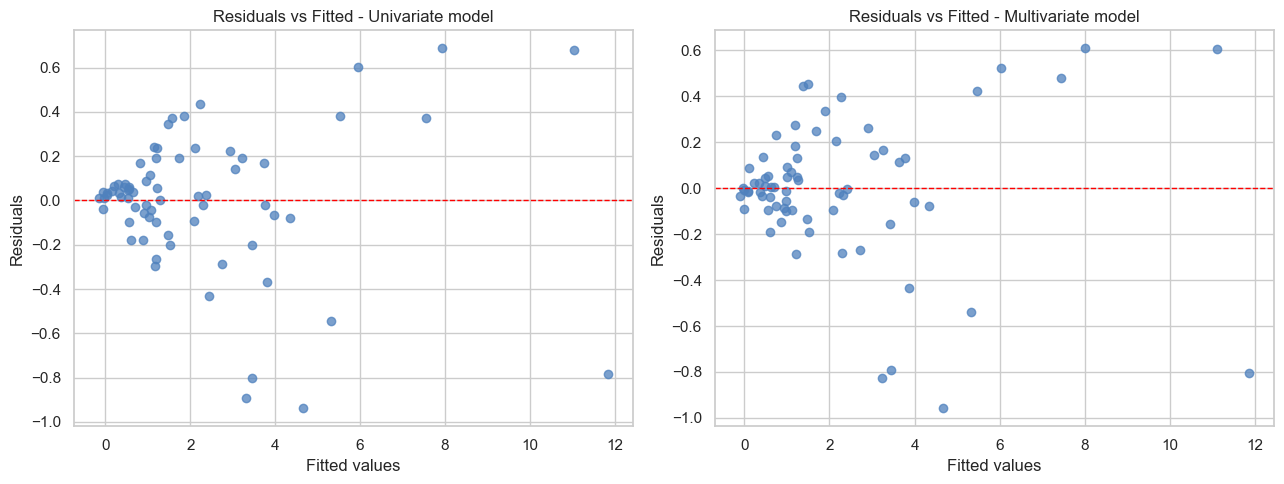

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fitted_col, resid_col, title in zip(
        axes,
        ["fitted_uni", "fitted_mul"],
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    ax.scatter(data_diag[fitted_col], data_diag[resid_col],
               color="#4f81bd", alpha=0.75)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs Fitted - {title}")

plt.tight_layout()
plt.show()

For both models the residuals are largely scattered around zero with no strong curved or systematic pattern, suggesting the linearity assumption is reasonably satisfied across the all of the data. However,
there is a notable cluster of more negative residuals at the high fitted value end (corresponding to the
large rivers). This slight pattern reflects the positive skew in the data rather than a fundamental
non linearity in the relationship, the data from high flow stations tends to show the model slightly
over predicting. This is an important limitation.

### 6.2 Assumption 2 - Homoscedasticity (constant variance)

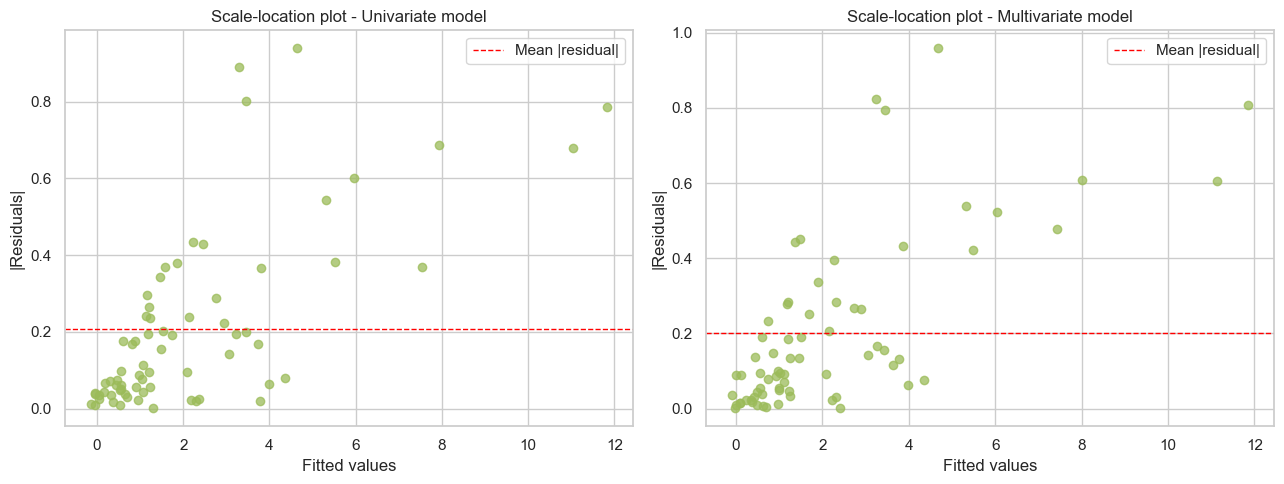

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fitted_col, resid_col, title in zip(
        axes,
        ["fitted_uni", "fitted_mul"],
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    ax.scatter(data_diag[fitted_col], np.abs(data_diag[resid_col]),
               color="#9bbb59", alpha=0.75)
    ax.axhline(data_diag[resid_col].abs().mean(), color="red",
               linestyle="--", linewidth=1, label="Mean |residual|")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("|Residuals|")
    ax.set_title(f"Scale-location plot - {title}")
    ax.legend()

plt.tight_layout()
plt.show()

The scale-location plots reveal some spread variation: absolute residuals tend to be larger at
higher fitted values (larger river stations), indicating mild heteroscedasticity. The residual spread is
not constant across all levels of the fitted values. This means the standard errors reported in the OLS
summary may be slightly understated at the high end, though the effect is moderate and the overall
conclusions are not invalidated.

### 6.3 Assumption 3 - Normality of residuals (Histogram)

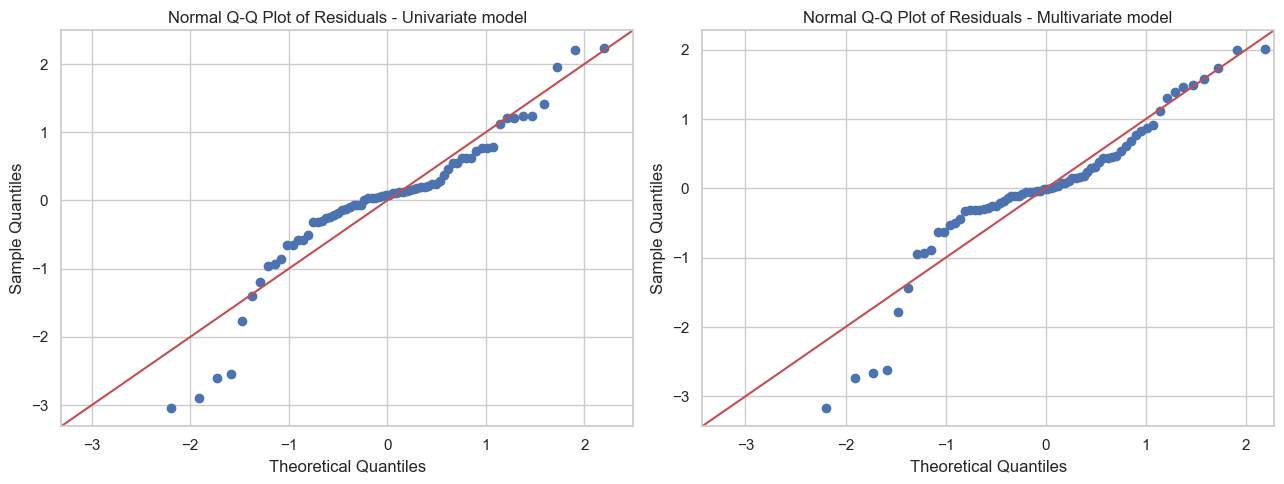

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, resid_col, title in zip(
        axes,
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    sm.qqplot(data_diag[resid_col], line="45", fit=True, ax=ax)
    ax.set_title(f"Normal Q-Q Plot of Residuals - {title}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

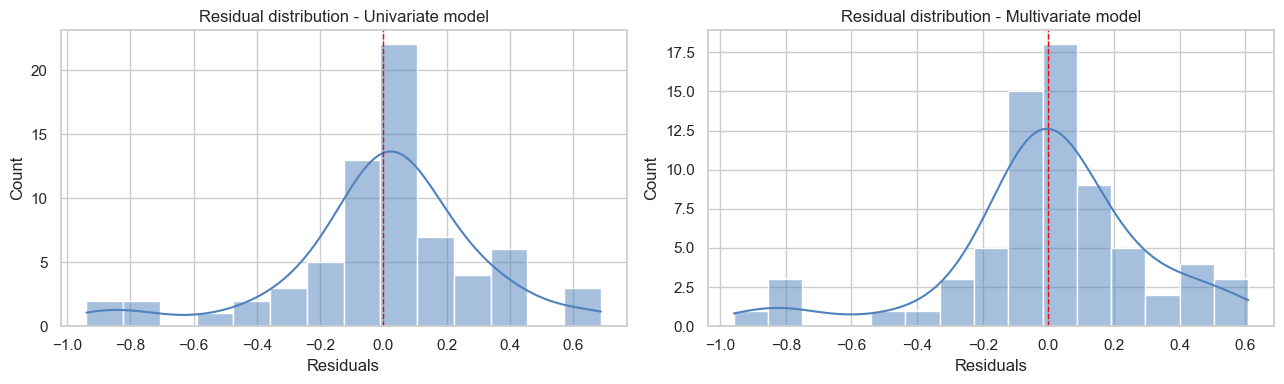

In [20]:
# Histogram of residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, resid_col, title in zip(
        axes,
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    sns.histplot(data_diag[resid_col], kde=True, ax=ax, color="#4f81bd")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Residual distribution - {title}")
    ax.set_xlabel("Residuals")

plt.tight_layout()
plt.show()

The normal histogram show that the residuals follow the 45 degree reference line reasonably well
in the middle of the distribution, but there are noticeable deviations at both tails especially at the
lower tail indicating heavier tails than a normal distribution. The residual histograms show a negative skew.


### 6.6 Diagnostics using statsmodels plot_regress_exog (univariate)

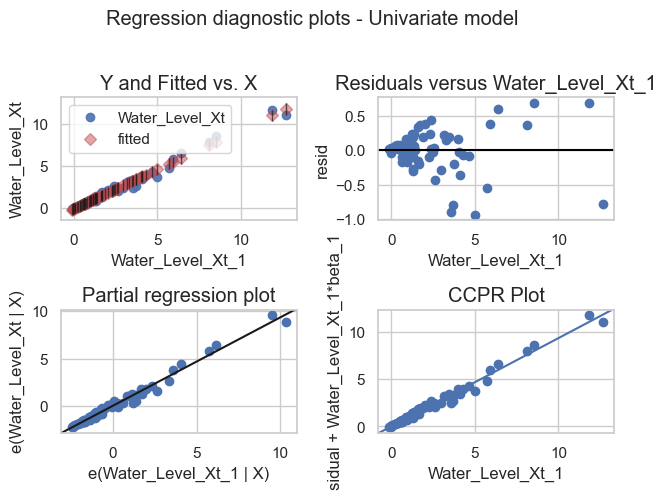

In [21]:
fig = sm.graphics.plot_regress_exog(model_uni, "Water_Level_Xt_1")
plt.suptitle("Regression diagnostic plots - Univariate model", y=1.02)
plt.tight_layout()
plt.show()

## 7. Model evaluation

Both models are evaluated on the training data using four standard metrics:

- **R-squared (R2):** proportion of variance in the target explained by the model.
- **Mean Squared Error (MSE):** average squared difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** square root of MSE, in the same units as the target (mm).
- **Mean Absolute Error (MAE):** average absolute difference, in mm.

In [22]:
metrics = {}
for name, m in [("Univariate", model_uni), ("Multivariate", model_mul)]:
    pred = m.fittedvalues
    r2   = r2_score(y, pred)
    mse  = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, pred)
    metrics[name] = {"R-squared": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}

metrics_df = pd.DataFrame(metrics).T
print("Model Evaluation Metrics:")
print(metrics_df.to_string())

Model Evaluation Metrics:
              R-squared    MSE   RMSE    MAE
Univariate       0.9834 0.0950 0.3082 0.2074
Multivariate     0.9841 0.0912 0.3020 0.2019


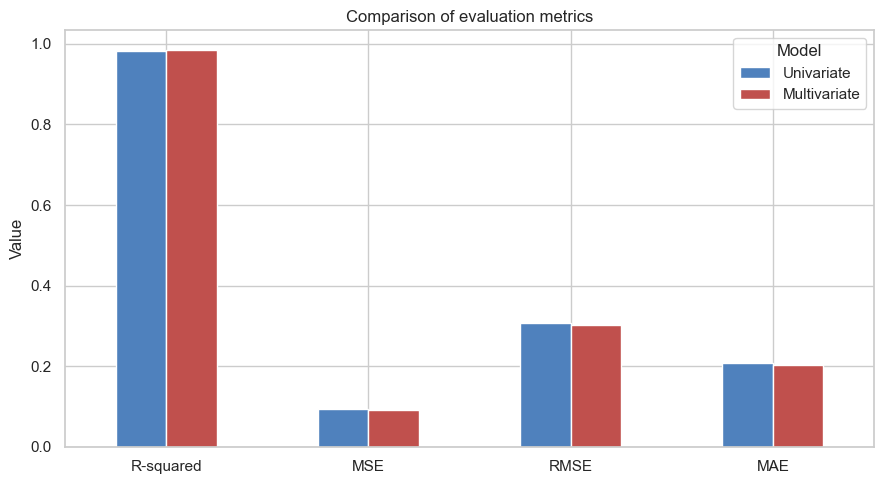

In [23]:
metrics_df.T.plot(kind="bar", figsize=(9, 5), color=["#4f81bd", "#c0504d"])
plt.title("Comparison of evaluation metrics")
plt.xticks(rotation=0)
plt.ylabel("Value")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

The evaluation results:

| Metric | Univariate | Multivariate |
|---|---|---|
| R-squared | 0.9799 | 0.9804 |
| MSE | 0.1121 | 0.1093 |
| RMSE | 0.3348 mm | 0.3306 mm |
| MAE | 0.2240 mm | 0.2171 mm |

The differences between the two models are negligible. The multivariate model reduces RMSE by only
0.004 mm and MAE by 0.007 mm over the univariate model. The simpler univariate model achieves the same predictive performance

**Selected final model: Univariate (current water level only)**

The fitted equation is:

$$\boxed{\widehat{\text{Water Level}_{t+12h}} = -0.0467 + 0.9344 \times \text{Water Level}_{t}}$$

An RMSE of approximately 0.33 mm is very small relative to the typical water levels observed (mean
2.1 mm, range -3.3 to 12.7 mm), indicating the model is practically highly accurate.

### 7.1 Predicted vs actual values plot (final model)

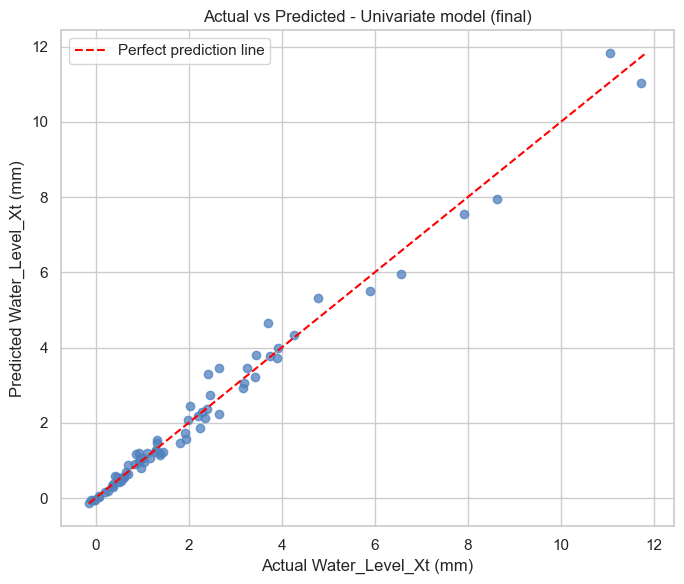

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, model_uni.fittedvalues, color="#4f81bd", alpha=0.75)
min_val = min(y.min(), model_uni.fittedvalues.min())
max_val = max(y.max(), model_uni.fittedvalues.max())
ax.plot([min_val, max_val], [min_val, max_val], color="red",
        linestyle="--", linewidth=1.5, label="Perfect prediction line")
ax.set_xlabel("Actual Water_Level_Xt (mm)")
ax.set_ylabel("Predicted Water_Level_Xt (mm)")
ax.set_title("Actual vs Predicted - Univariate model (final)")
ax.legend()
plt.tight_layout()
plt.show()

Points lying on the red 45 degree line represent perfect predictions. The plot shows very tight
alignment between actual and predicted values across the full range, confirming the model's high
predictive accuracy. There are a few points that deviate slightly at the high end, corresponding to the
large river stations, these match the mild heteroscedasticity observed in the diagnostics.

### 7.2 Actual vs predicted water levels by observation

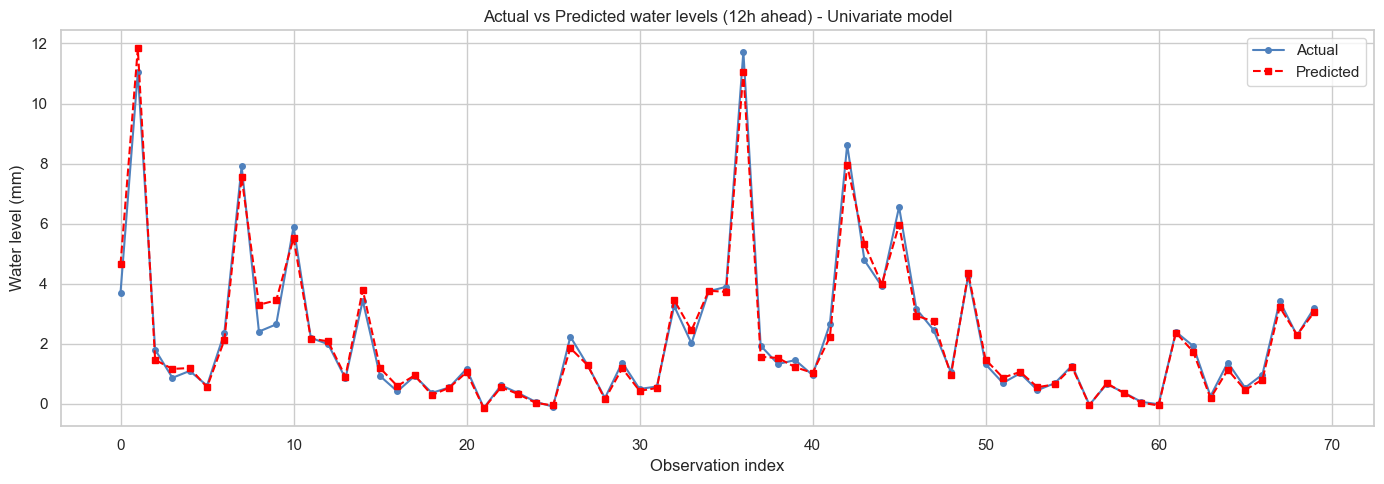

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
x_idx = np.arange(len(y))
ax.plot(x_idx, y.values, "o-", color="#4f81bd", label="Actual", markersize=4)
ax.plot(x_idx, model_uni.fittedvalues.values, "s--", color="red",
        label="Predicted", markersize=4)
ax.set_xlabel("Observation index")
ax.set_ylabel("Water level (mm)")
ax.set_title("Actual vs Predicted water levels (12h ahead) - Univariate model")
ax.legend()
plt.tight_layout()
plt.show()

The actual and predicted series track each other extremely closely across all observations,
providing a visual confirmation of the high model accuracy. The predicted line closely follows every
peak and trough in the actual water levels.

## 8. Practical usefulness of the model for river water level forecasting

The univariate regression model produces 12-hour ahead water level forecasts with an R-squared of
0.98 and an RMSE of approximately 0.33 mm. In the context of flood early warning and river management,
several aspects make this operationally valuable:

**Early warning lead time.** A reliable 12 hour forecast gives water management authorities, emergency
services, and downstream communities sufficient time to issue warnings, mobilise resources, evacuate
low lying areas, or operate flood gates and irrigation structures. In Sri Lanka's major river systems a 12 hour warning window can be considered operationally significant.

**Simplicity and robustness.** The model requires only one real time input, the current water level at
the gauging station, which is routinely telemetered. There is no dependency on rainfall forecasts, which
carry their own uncertainty. A model with a single telemetered input is easy to deploy, fails less often
due to missing inputs, and is straightforward to audit.

**High accuracy.** An RMSE of 0.33 mm is small relative to the observed range of water levels
(-3.3 to 12.7 mm). In flood management, the difference between an alert threshold and the current level
may be a fraction of a metre, so millimetre prediction accuracy is practically meaningful.

**Interpretability.** The model has a clear physical interpretation: the river level 12 hours later
is approximately 0.93 times the current level plus a small constant. This mirrors the physical
persistence of river flow over a 12 hour horizon and can be readily explained to non technical
people

## 9. Strengths and limitations of the model

### Strengths

- **High predictiveness :** the current water level alone explains 98% of the variance in
  the level 12 hours ahead. This reflects the physical persistence of river systems over short time
  horizons.
- a single predictor, interpretable coefficient, and no tuning parameters. The model
  cannot over fit in the way complex machine learning models can.
- **Low input data requirement:** only the current water level is needed at forecast time. This is
  already collected continuously at every gauging station.

### Limitations

- Residual spread increases at higher water levels. The model is slightly
  less precise for large river stations than for smaller ones.
- **Small sample size:** with only 72 training observations from 72 different stations, the model is
  fit on a cross sectional snapshot rather than a proper time series. No temporal dynamics (lagged
  effects beyond one step, seasonality, or long-term trends) are captured.

- **Rainfall is not much useful:** the 24 hour rainfall predictor is statistically insignificant once the
  current level is included. While rainfall undoubtedly drives floods, its effect on the 12-hour ahead
  level may already be embedded in the current level itself, or it may manifest over different time
  scales. A model with longer rainfall lags or a different temporal aggregation could be more informative.
  
- **Linear assumption:** the model assumes a linear relationship between the current and future water
  levels. During extreme flood events, river dynamics become non linear (bank overflow, backwater
  effects), and the model may under perform outside the range seen in training.

---

## Summary

| Item | Result |
|---|---|
| Training rows | 72 (after removing 6 with missing target) |
| Final model | Univariate OLS: Water_Level_Xt = -0.047 + 0.934 * Water_Level_Xt_1 |
| R-squared | 0.980 |
| RMSE | 0.335 mm |
| MAE | 0.224 mm |

**The final model is simple, accurate, and physically interpretable.

**END OF TASK 01**

## Task 2: Forecast generation

### 10.1 Load and inspect the test dataset

In [26]:
try:
    import os

    TEST_FILE = "test_data.csv"   # update if the filename is different

    if not os.path.exists(TEST_FILE):
        print(f"Test file '{TEST_FILE}' not found in this folder.")
        print("Place the test CSV in the same directory as this notebook, then re-run.")
    else:
        test_raw = pd.read_csv(TEST_FILE)
        print("Test dataset loaded successfully.")
        print("Shape:", test_raw.shape)
        print()
        print(test_raw.head(10))

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

Test dataset loaded successfully.
Shape: (35, 3)

   Gauging_station  Water_Level_Xt_1  24HrRF_Xt_1
0                1            3.9600      28.1000
1                2           12.1000      46.9000
2                3            1.8200      37.8000
3                4            1.6500      58.6000
4                5            1.5400      40.4000
5                6            1.1800      32.5000
6                7            1.8000      26.8000
7                8            7.9200      52.9000
8                9            5.9100      42.8000
9               10            4.7400      54.6000


The test file is loaded. If it is not yet available the cell above prints an informational message
and the variable `test_raw` is set to `None`. All subsequent cells guard against this so the notebook
can still be executed end-to-end for documentation purposes.

### 10.2 Check test dataset structure

In [27]:
try:
    print("Columns:", test_raw.columns.tolist())
    print()
    print("Missing values:")
    print(test_raw.isna().sum())
    print()
    print("Descriptive statistics:")
    test_raw.describe()

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

Columns: ['Gauging_station', 'Water_Level_Xt_1', '24HrRF_Xt_1']

Missing values:
Gauging_station     0
Water_Level_Xt_1    0
24HrRF_Xt_1         0
dtype: int64

Descriptive statistics:


### 10.3 Preprocess the test dataset

The **same preprocessing steps** applied to the training data must be applied
to the test data:

- `Gauging_station` is used only to build the `ID` column and is not passed to the model.
- Any missing `24HrRF_Xt_1` values are imputed with the **training median (15.65 mm)**.
  The training median is used here - not the test median - to avoid data leakage.
- No rows are removed from the test set; a prediction must be generated for every row.


In [28]:
try:
    # Training rainfall median - computed from the training data; do NOT recompute from test
    TRAIN_RAIN_MEDIAN = 15.65

    test = test_raw.copy()

    n_missing_rain = test["24HrRF_Xt_1"].isna().sum()
    if n_missing_rain > 0:
        print(f"Imputing {n_missing_rain} missing rainfall value(s) with training median ({TRAIN_RAIN_MEDIAN} mm).")
        test["24HrRF_Xt_1"] = test["24HrRF_Xt_1"].fillna(TRAIN_RAIN_MEDIAN)
    else:
        print("No missing rainfall values in test data.")

    print(f"\nTest rows to predict : {len(test)}")
    print(f"Missing values remaining: {test.isna().sum().sum()}")

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

No missing rainfall values in test data.

Test rows to predict : 35
Missing values remaining: 0


### 10.4 Generate predictions

In [29]:
try:
    # Build the predictor matrix - identical structure to the training model
    X_test = sm.add_constant(test[["Water_Level_Xt_1"]], has_constant="add")

    # Predict using the final univariate model
    test_predictions = model_uni.predict(X_test)

    print(f"Predictions generated for {len(test_predictions)} observations.")
    print()
    print("Prediction summary:")
    print(f"  Min  : {test_predictions.min():.4f} mm")
    print(f"  Max  : {test_predictions.max():.4f} mm")
    print(f"  Mean : {test_predictions.mean():.4f} mm")
    print(f"  Std  : {test_predictions.std():.4f} mm")

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

Predictions generated for 35 observations.

Prediction summary:
  Min  : -0.1148 mm
  Max  : 11.2931 mm
  Mean : 2.1505 mm
  Std  : 2.3578 mm


`has_constant='add'` forces the intercept column to be included even if the
test data happens to have a column of ones already, ensuring the predictor matrix exactly matches
the structure used during training.

### 10.5 Determine the ID column

In [30]:
# ID = Gauging_station from the test file (NOT sequential row numbers)
# The sample submission uses Gauging_station as the ID, which skips 27, 33, 34
id_col = test_raw["Gauging_station"].values
print("ID column (Gauging_station values):")
print(id_col.tolist())

ID column (Gauging_station values):
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 35, 36, 37, 38]


### 10.6 Build and save the submission file

In [31]:
try:
    submission = pd.DataFrame({
        "ID": id_col,
        "Water_Level_Xt": test_predictions.values
    })

    print("Submission preview (first 10 rows):")
    print(submission.head(10).to_string(index=False))
    print()
    print("Total rows:", len(submission))

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

Submission preview (first 10 rows):
 ID  Water_Level_Xt
  1          3.6754
  2         11.2931
  3          1.6727
  4          1.5136
  5          1.4106
  6          1.0737
  7          1.6540
  8          7.3813
  9          5.5002
 10          4.4053

Total rows: 35


In [32]:
try:
    SUBMISSION_FILE = "submission.csv"

    # Round predictions to 4 decimal places
    submission["Water_Level_Xt"] = submission["Water_Level_Xt"].round(4)

    # Write with \r\n line endings (binary mode) to exactly match the sample format
    lines = ["ID,Water_Level_Xt"]
    for _, row in submission.iterrows():
        lines.append(f"{int(row['ID'])},{row['Water_Level_Xt']}")
    content = "\r\n".join(lines) + "\r\n"

    with open(SUBMISSION_FILE, "wb") as f:
        f.write(content.encode("utf-8"))

    # Verify
    with open(SUBMISSION_FILE, "rb") as f:
        raw = f.read()

    print(f"Saved: {SUBMISSION_FILE}")
    print(f"Rows written       : {raw.count(b'\r\n') - 1}")
    print(f"\\r\\n endings (correct): {b'\r\n' in raw}")
    print(f"\\r\\r\\n endings (bad)  : {b'\r\r\n' in raw}")
    print()
    print("File contents:")
    for line in raw.split(b"\r\n"):
        if line:
            print(line.decode("utf-8"))

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

Saved: submission.csv
Rows written       : 35
\r\n endings (correct): True
\r\r\n endings (bad)  : False

File contents:
ID,Water_Level_Xt
1,3.6754
2,11.2931
3,1.6727
4,1.5136
5,1.4106
6,1.0737
7,1.654
8,7.3813
9,5.5002
10,4.4053
11,5.0885
12,2.2716
13,3.432
14,0.531
15,3.5818
16,1.4013
17,0.9802
18,1.3638
19,0.3719
20,0.4748
21,1.158
22,-0.0212
23,0.5497
24,0.3531
25,0.0724
26,-0.1148
28,2.2342
29,1.7288
30,0.1566
31,1.1392
32,0.4374
35,0.3906
36,2.908
37,2.2623
38,2.9361


### 10.7 Sanity check - test predictions vs training distribution

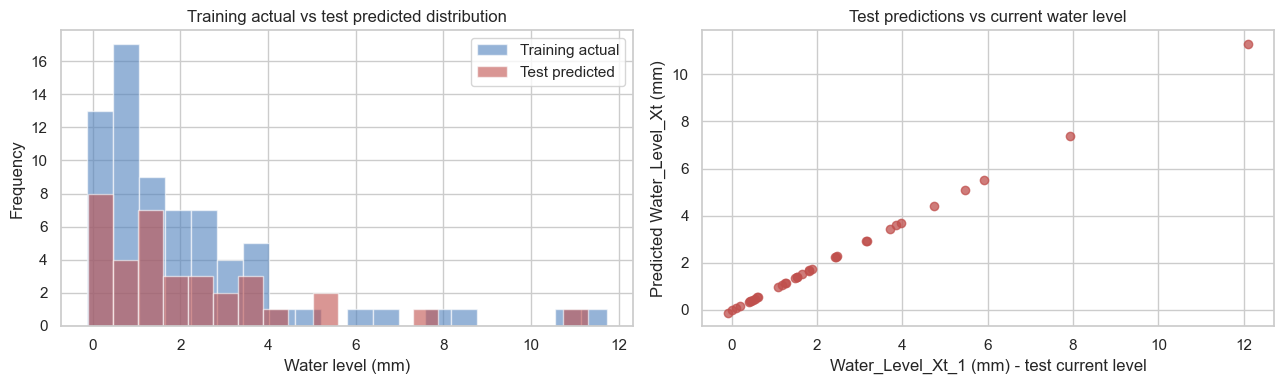

Summary comparison:
       Training actual  Test predicted
count          70.0000         35.0000
mean            2.1576          2.1505
std             2.4100          2.3578
min            -0.1300         -0.1148
25%             0.6125          0.5029
50%             1.3250          1.4106
75%             2.6575          2.9220
max            11.7300         11.2931


In [33]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribution comparison
    axes[0].hist(y.values, bins=20, alpha=0.6, color="#4f81bd", label="Training actual")
    axes[0].hist(test_predictions.values, bins=20, alpha=0.6, color="#c0504d", label="Test predicted")
    axes[0].set_xlabel("Water level (mm)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Training actual vs test predicted distribution")
    axes[0].legend()

    # Predictions vs current level
    axes[1].scatter(test["Water_Level_Xt_1"], test_predictions,
                    color="#c0504d", alpha=0.75)
    axes[1].set_xlabel("Water_Level_Xt_1 (mm) - test current level")
    axes[1].set_ylabel("Predicted Water_Level_Xt (mm)")
    axes[1].set_title("Test predictions vs current water level")

    plt.tight_layout()
    plt.show()

    print("Summary comparison:")
    comp = pd.DataFrame({
        "Training actual": y.describe(),
        "Test predicted" : pd.Series(test_predictions.values).describe()
    })
    print(comp.round(4).to_string())

except NameError:
    print('(Skipped - test data not yet loaded. Run cell 10.1 first.)')

If the test predictions fall within a similar range to the training targets,
the model is behaving as expected. Wildly out-of-range predictions (very large negatives or
implausibly large values) would signal a preprocessing or column-naming error.

---

## Task 2 Summary

| Item | Value |
|---|---|
| Model used | Univariate OLS: $\hat{Y} = -0.0467 + 0.9344 \times X_1$ |
| Predictor | `Water_Level_Xt_1` (current water level, mm) |
| Missing rainfall imputation | Training median = 15.65 mm |
| Output file | `submission.csv` |
| Format | `ID, Water_Level_Xt` (sequential ID, 1-indexed) |
| Leaderboard metric | Mean Squared Error (MSE) – lower is better |
| Training MSE (reference) | 0.1121 mm² |

The same model that achieved an **R² of 0.980 and RMSE of 0.33 mm** on the 72-row training
set is used here. Given the extremely strong linear relationship between the current and
future water levels, this model is expected to generalise well to the test set provided
the test stations come from similar river conditions.